# 静态场景 - 密度扫描实验
固定业务比例，扫描不同总密度下的性能表现

## 初始化环境

In [1]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（包括static_sensitivity_config和load_yaml_config）
from utils.evaluate import (
    static_sensitivity_config,
    train_and_evaluate_scenario,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 密度扫描配置生成

In [3]:
def run_density_sweep_experiment():
    """
    密度扫描实验：固定业务比例，扫描总密度
    用于绘制：Throughput vs. Density 曲线
    """
    # 1. 定义几个固定的业务混合模式
    traffic_mixes = {
        "Balanced": {'cbra': 0.4, 'pbra': 0.35, 'cfra': 0.25},
    }

    # 2. 定义要扫描的密度范围
    densities = [5.0, 10.0, 25.0, 40.0]
    configs = []

    print("--- Generating Density Sweep Configs ---")
    for mix_name, ratios in traffic_mixes.items():
        for d in densities:
            cfg = static_sensitivity_config(
                total_density=d,
                cbra_ratio=ratios['cbra'],
                pbra_ratio=ratios['pbra'],
                cfra_ratio=ratios['cfra']
            )
            label = f"{mix_name}_D{int(d)}"
            configs.append((label, cfg))
            print(f"Generated: [{label}]")

    return configs

# 生成配置
density_sweep_configs = run_density_sweep_experiment()
print(f"\n总共生成 {len(density_sweep_configs)} 个密度扫描场景配置")

--- Generating Density Sweep Configs ---
Generated: [Balanced_D5]
Generated: [Balanced_D10]
Generated: [Balanced_D25]
Generated: [Balanced_D40]

总共生成 4 个密度扫描场景配置


## 加载训练配置

In [4]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_density_sweep_Balanced.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f"Warning: Could not remove existing log file: {e}")
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for density sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=10,
    decision_horizon=100,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=3200,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=500,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(density_sweep_configs)} 个场景待训练")


2025-12-03 22:23:53 | INFO     | Logger initialized for density sweep experiment


Loaded configuration from conf\default.yaml
配置加载完成: 4 个场景待训练


2025-12-03 22:23:53 | INFO     | Config ready | seed=42 num_envs=8


## 执行密度扫描训练

In [5]:
# 全局结果存储
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始批量训练 {len(density_sweep_configs)} 个密度扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(density_sweep_configs):
    print(f"\n[{idx+1}/{len(density_sweep_configs)}] 当前场景: {label}")
    try:
        result = train_and_evaluate_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            run_episode_func=run_episode,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            num_episodes=20,
            seed=seed
        )
        all_scenarios_results[label] = result
    except Exception as e:
        print(f"场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_scenarios_results)}/{len(density_sweep_configs)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)


开始批量训练 4 个密度扫描场景


[1/4] 当前场景: Balanced_D5

开始训练场景: Balanced_D5
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.4_P0.3_F0.2', cbra_density=2.0, pbra_density=1.75, cfra_density=1.25),), segments=(RegionSegment(region_name='static_D5.0_C0.4_P0.3_F0.2', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-03 22:23:53,994 [torchrl][INFO]    The info_dict_reader does not have specs. The onl

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-03 22:23:57 | INFO     | Starting PPO training for scenario: Balanced_D5


  iter=0000, reward=-2.0591
  iter=0010, reward=0.4555
  iter=0010, reward=0.4555
  iter=0020, reward=0.6752
  iter=0020, reward=0.6752
  iter=0030, reward=0.8589
  iter=0030, reward=0.8589
  iter=0040, reward=1.0337
  iter=0040, reward=1.0337
  iter=0050, reward=1.1584
  iter=0050, reward=1.1584
  iter=0060, reward=1.1676
  iter=0060, reward=1.1676
  iter=0070, reward=1.2130
  iter=0070, reward=1.2130
  iter=0080, reward=1.3155
  iter=0080, reward=1.3155
  iter=0090, reward=1.3448
  iter=0090, reward=1.3448
  iter=0100, reward=1.3798
  iter=0100, reward=1.3798
  iter=0110, reward=1.4445
  iter=0110, reward=1.4445
  iter=0120, reward=1.4423
  iter=0120, reward=1.4423
  iter=0130, reward=1.5272
  iter=0130, reward=1.5272
  iter=0140, reward=1.5698
  iter=0140, reward=1.5698
  iter=0150, reward=1.5743
  iter=0150, reward=1.5743
  iter=0160, reward=1.6199
  iter=0160, reward=1.6199
  iter=0170, reward=1.5975
  iter=0170, reward=1.5975
  iter=0180, reward=1.5972
  iter=0180, reward=1.5972


2025-12-03 23:23:03 | INFO     | Starting PPO training for scenario: Balanced_D10


  iter=0000, reward=0.0144
  iter=0010, reward=0.7570
  iter=0010, reward=0.7570
  iter=0020, reward=1.1782
  iter=0020, reward=1.1782
  iter=0030, reward=1.2100
  iter=0030, reward=1.2100
  iter=0040, reward=1.3230
  iter=0040, reward=1.3230
  iter=0050, reward=1.4565
  iter=0050, reward=1.4565
  iter=0060, reward=1.5680
  iter=0060, reward=1.5680
  iter=0070, reward=1.5997
  iter=0070, reward=1.5997
  iter=0080, reward=1.7036
  iter=0080, reward=1.7036
  iter=0090, reward=1.7633
  iter=0090, reward=1.7633
  iter=0100, reward=1.7974
  iter=0100, reward=1.7974
  iter=0110, reward=1.7758
  iter=0110, reward=1.7758
  iter=0120, reward=1.7792
  iter=0120, reward=1.7792
  iter=0130, reward=1.7844
  iter=0130, reward=1.7844
  iter=0140, reward=1.8163
  iter=0140, reward=1.8163
  iter=0150, reward=1.7040
  iter=0150, reward=1.7040
  iter=0160, reward=1.8558
  iter=0160, reward=1.8558
  iter=0170, reward=-0.2666
  iter=0170, reward=-0.2666
  iter=0180, reward=0.0221
  iter=0180, reward=0.0221

2025-12-04 01:53:19 | INFO     | Starting PPO training for scenario: Balanced_D25


  iter=0000, reward=-0.7627
  iter=0010, reward=-0.2055
  iter=0010, reward=-0.2055
  iter=0020, reward=0.1190
  iter=0020, reward=0.1190
  iter=0030, reward=0.5281
  iter=0030, reward=0.5281
  iter=0040, reward=0.7578
  iter=0040, reward=0.7578
  iter=0050, reward=1.0305
  iter=0050, reward=1.0305
  iter=0060, reward=0.9049
  iter=0060, reward=0.9049
  iter=0070, reward=0.8733
  iter=0070, reward=0.8733
  iter=0080, reward=1.2678
  iter=0080, reward=1.2678
  iter=0090, reward=1.2613
  iter=0090, reward=1.2613
  iter=0100, reward=1.5869
  iter=0100, reward=1.5869
  iter=0110, reward=1.6567
  iter=0110, reward=1.6567
  iter=0120, reward=1.7968
  iter=0120, reward=1.7968
  iter=0130, reward=1.8343
  iter=0130, reward=1.8343
  iter=0140, reward=1.9104
  iter=0140, reward=1.9104
  iter=0150, reward=0.2341
  iter=0150, reward=0.2341
  iter=0160, reward=1.1569
  iter=0160, reward=1.1569
  iter=0170, reward=1.5780
  iter=0170, reward=1.5780
  iter=0180, reward=1.7555
  iter=0180, reward=1.755

2025-12-04 04:23:25 | INFO     | Starting PPO training for scenario: Balanced_D40


  iter=0000, reward=-4.8622
  iter=0010, reward=-0.7230
  iter=0010, reward=-0.7230
  iter=0020, reward=-0.4163
  iter=0020, reward=-0.4163
  iter=0030, reward=-0.3396
  iter=0030, reward=-0.3396
  iter=0040, reward=-0.1972
  iter=0040, reward=-0.1972
  iter=0050, reward=-0.0646
  iter=0050, reward=-0.0646
  iter=0060, reward=0.1374
  iter=0060, reward=0.1374
  iter=0070, reward=0.3343
  iter=0070, reward=0.3343
  iter=0080, reward=0.4569
  iter=0080, reward=0.4569
  iter=0090, reward=0.6125
  iter=0090, reward=0.6125
  iter=0100, reward=1.1594
  iter=0100, reward=1.1594
  iter=0110, reward=1.3214
  iter=0110, reward=1.3214
  iter=0120, reward=1.4892
  iter=0120, reward=1.4892
  iter=0130, reward=1.5383
  iter=0130, reward=1.5383
  iter=0140, reward=1.5715
  iter=0140, reward=1.5715
  iter=0150, reward=1.6339
  iter=0150, reward=1.6339
  iter=0160, reward=0.0196
  iter=0160, reward=0.0196
  iter=0170, reward=0.4926
  iter=0170, reward=0.4926
  iter=0180, reward=1.2336
  iter=0180, rewa

In [6]:
env_config

SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='suburban', cbra_density=1.0, pbra_density=3.5, cfra_density=0.5), RegionTrafficProfile(name='periurbanType1', cbra_density=3.0, pbra_density=3.0, cfra_density=9.0), RegionTrafficProfile(name='periurbanType2', cbra_density=3.0, pbra_density=10.5, cfra_density=1.5), RegionTrafficProfile(name='urban', cbra_density=56.0, pbra_density=16.0, cfra_density=8.0)), segments=(RegionSegment(region_name='suburban', length=2.0), RegionSegment(region_name='periurbanType1', length=2.5), RegionSegment(region_name='urban', length=5.0), RegionSegment(region_name='periurbanType2', length=1.5), RegionSegment(region_name='suburban', length=2.0)), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=Back

In [7]:
all_scenarios_results['Balanced_D100']['eval_results_last']

KeyError: 'Balanced_D100'

## 可视化密度扫描结果

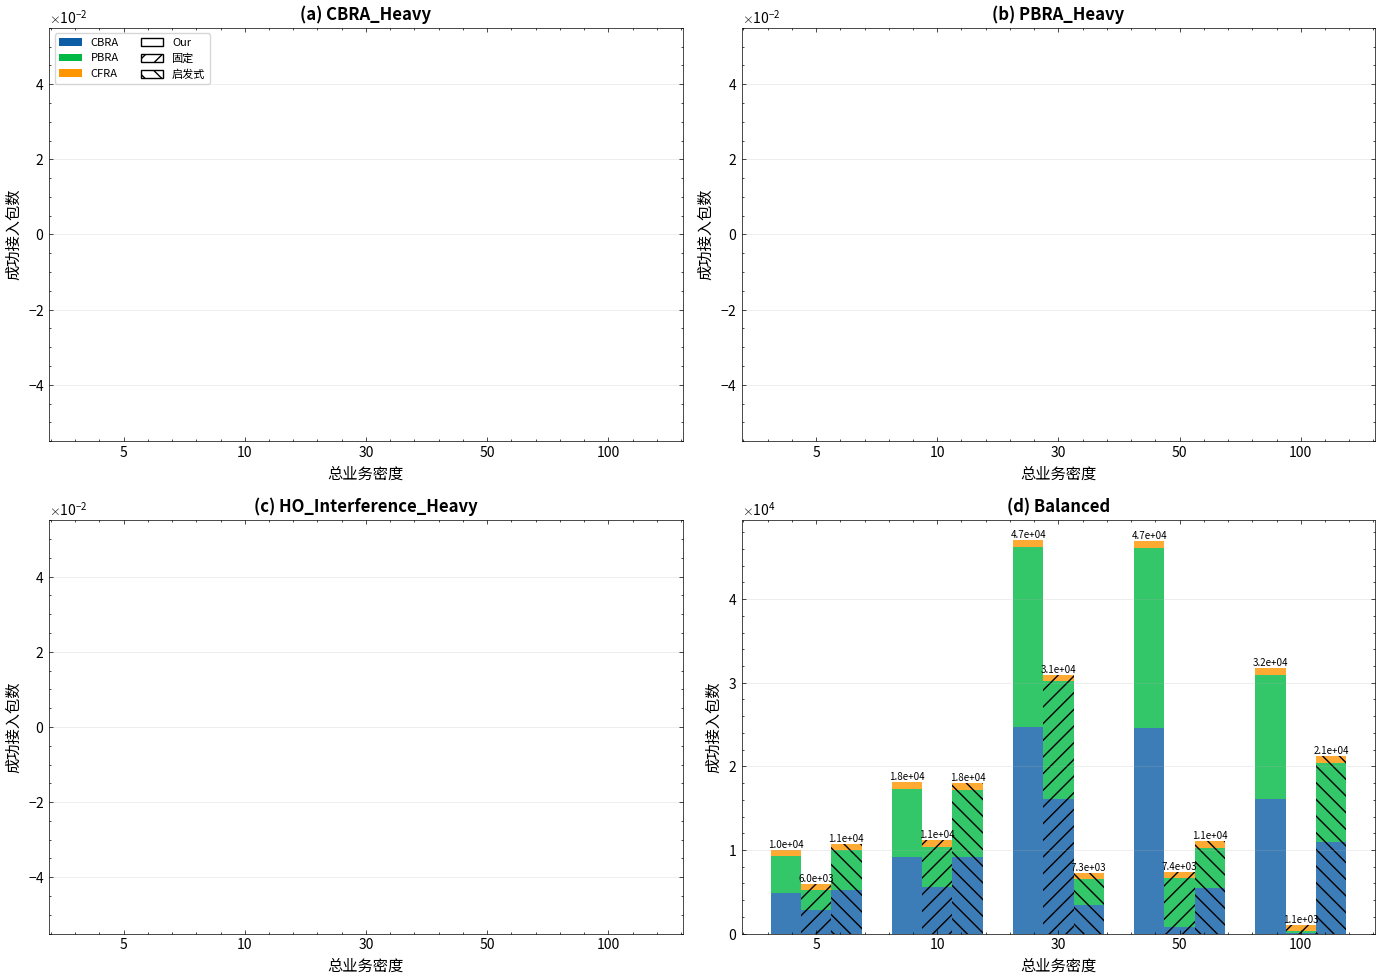

密度扫描对比图已保存到: output/static/density_sweep_comparison.svg


In [ ]:
def plot_density_sweep_results():
    """绘制密度扫描实验结果 - 单个流量模式的图"""
    traffic_mixes = ["Balanced"]
    densities = [5.0, 10.0, 25.0, 40.0]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    for mix_idx, mix_name in enumerate(traffic_mixes):
        # 收集数据
        ppo_cbra = []
        ppo_pbra = []
        ppo_cfra = []
        ppo_theo = []
        fixed_cbra = []
        fixed_pbra = []
        fixed_cfra = []
        fixed_theo = []
        heuristic_cbra = []
        heuristic_pbra = []
        heuristic_cfra = []
        heuristic_theo = []
        total_arrivals_list = []

        for d in densities:
            label = f"{mix_name}_D{int(d)}"
            if label in all_scenarios_results:
                result = all_scenarios_results[label]

                # PPO最佳模型
                ppo_cbra.append(result['eval_results_last']['eval_success_cbra'])
                ppo_pbra.append(result['eval_results_last']['eval_success_pbra'])
                ppo_cfra.append(result['eval_results_last']['eval_success_cfra'])
                ppo_theo.append(result['eval_results_last'].get('eval_theoretical_optimal', 0))

                # 固定分配
                fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
                fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
                fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])
                fixed_theo.append(result['baseline_results']['固定分配'].get('theoretical_optimal', 0))

                # 启发式算法
                heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
                heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
                heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])
                heuristic_theo.append(result['baseline_results']['启发式算法'].get('theoretical_optimal', 0))

                # 获取总到达包数 (使用固定分配的到达数作为参考)
                total_arr = (result['baseline_results']['固定分配']['arrivals_cbra'] +
                           result['baseline_results']['固定分配']['arrivals_pbra'] +
                           result['baseline_results']['固定分配']['arrivals_cfra'])
                total_arrivals_list.append(total_arr)
            else:
                ppo_cbra.append(0)
                ppo_pbra.append(0)
                ppo_cfra.append(0)
                ppo_theo.append(0)
                fixed_cbra.append(0)
                fixed_pbra.append(0)
                fixed_cfra.append(0)
                fixed_theo.append(0)
                heuristic_cbra.append(0)
                heuristic_pbra.append(0)
                heuristic_cfra.append(0)
                heuristic_theo.append(0)
                total_arrivals_list.append(0)

        ppo_cbra = np.array(ppo_cbra)
        ppo_pbra = np.array(ppo_pbra)
        ppo_cfra = np.array(ppo_cfra)
        ppo_theo = np.array(ppo_theo)
        fixed_cbra = np.array(fixed_cbra)
        fixed_pbra = np.array(fixed_pbra)
        fixed_cfra = np.array(fixed_cfra)
        fixed_theo = np.array(fixed_theo)
        heuristic_cbra = np.array(heuristic_cbra)
        heuristic_pbra = np.array(heuristic_pbra)
        heuristic_cfra = np.array(heuristic_cfra)
        heuristic_theo = np.array(heuristic_theo)

        ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
        fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
        heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

        # 绘制堆叠柱状图
        x = np.arange(len(densities))
        width = 0.25

        # Our (最佳) - 实心
        p1_cbra = ax.bar(x - width, ppo_cbra, width, alpha=0.8, color='C0')
        p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, alpha=0.8, color='C1')
        p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, alpha=0.8, color='C2')

        # 固定分配 - 斜线填充
        p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
        p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
        p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

        # 启发式算法 - 反斜线填充
        p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\\\')
        p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\\\')
        p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\\\')

        # 添加理论最优值水平线 (使用平均值)
        avg_theo = np.mean([t for t in ppo_theo if t > 0])
        if avg_theo > 0:
            ax.axhline(avg_theo, color='red', linestyle='--', linewidth=2,
                      label=f'理论最优 (平均={int(avg_theo)})', zorder=10)

        # 标注总数和达最优率
        for i in range(len(densities)):
            if ppo_total[i] > 0:
                theo_rate = (ppo_total[i] / ppo_theo[i] * 100) if ppo_theo[i] > 0 else 0
                ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7, color='blue')
            if fixed_total[i] > 0:
                theo_rate = (fixed_total[i] / fixed_theo[i] * 100) if fixed_theo[i] > 0 else 0
                ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)
            if heuristic_total[i] > 0:
                theo_rate = (heuristic_total[i] / heuristic_theo[i] * 100) if heuristic_theo[i] > 0 else 0
                ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)

        ax.set_xlabel('总业务密度 (总包数)', fontsize=12)
        ax.set_ylabel('成功接入包数', fontsize=12)
        ax.set_title(f'{mix_name} - 密度扫描性能对比', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        # 横轴标签添加总包数信息
        xticklabels = [f'{int(d)}\n({int(arr):.1e})' if arr > 0 else f'{int(d)}'
                      for d, arr in zip(densities, total_arrivals_list)]
        ax.set_xticklabels(xticklabels, fontsize=10)

        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='C0', label='CBRA'),
            Patch(facecolor='C1', label='PBRA'),
            Patch(facecolor='C2', label='CFRA'),
            Patch(facecolor='white', edgecolor='black', label='Our'),
            Patch(facecolor='white', edgecolor='black', hatch='//', label='固定'),
            Patch(facecolor='white', edgecolor='black', hatch='\\\\', label='启发式'),
        ]
        ax.legend(handles=legend_elements, fontsize=10, frameon=True, loc='upper left', ncol=2)

        ax.tick_params(labelsize=11)
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs("output/static", exist_ok=True)
    plt.savefig("output/static/density_sweep_Balanced.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("密度扫描对比图已保存到: output/static/density_sweep_Balanced.svg")

# 绘制结果
plot_density_sweep_results()
